### Example kaggle
https://www.kaggle.com/code/tomforbes/optiver-trading-at-the-close-introduction <br/>
extra info: https://www.nasdaqtrader.com/content/productsservices/Trading/ClosingCrossfaq.pdf

#### Goal
Develop a model capable of predicting the closing price movements for hundreds of Nasdaq listed stocks using data from the order book and the closing auction of the stock.

**target**
-  The 60 second future move in the wap of the stock, less the 60 second future move of the synthetic index. Only provided for the train set.
- The unit of the target is basis points, which is a common unit of measurement in financial markets. A 1 basis point price move is equivalent to a 0.01% price move.

$$
\text{Target} =
\left(
\frac{\text{StockWAP}_{t+60}}{\text{StockWAP}_t}
-
\frac{\text{IndexWAP}_{t+60}}{\text{IndexWAP}_t}
\right)
\times 10000
$$

**wap**
$$
\frac{
\text{BidPrice} \times \text{AskSize}
+
\text{AskPrice} \times \text{BidSize}
}{
\text{BidSize} + \text{AskSize}
}
$$
Important: (MOC, LOC, IO) orders placed before 3:50 p.m. can be canceled or modified. Those places after may not be canceled or modified.

Between 3:50 p.m. ET and 3:55 p.m. ET<br/>
**Number of Paired Shares**: The number of on-close shares that Nasdaq is able to pair off at the current reference price.<br/>
**Imbalance Side**: Indicates the direction of the Imbalance. <br/>
**Imbalance Quantity**: The number of closing shares that are seeking additional liquidity at the current reference price. <br/>
**Current Reference Price**: The price within the Nasdaq Best Bid and Offer (BBO) at which paired shares are maximized. The  imbalance is minimized and the distance from the midpoint is minimized, in that order.<br/>
 <br/><br/>
Between 3:55 p.m. ET and 4:00 p.m. ET <br/> 
**Near Indicative Clearing Price**: 
The crossing price that will maximize the number of shares matched
based on on-close orders (MOC, LOC, IO) and
continuous market orders. Effectively, this is the
price at which the closing cross would occur at that
moment in time.

**Far Indicative Clearing Price**: 
The crossing price that will maximize the number of shares matched
based on closing interest only (MOC, LOC, IO). This
calculation excludes continuous market orders.

In [1]:
import pandas as pd 
import numpy as np
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
#from sklearn.compose import ColumnTransformer

### Create a validation set
train on first 400 days and choose last 81 days asvalidation set.*

*
as proposed by
https://www.kaggle.com/competitions/optiver-trading-at-the-close/writeups/hyd-1st-place-solution#2721451

data = pd.read_csv('../data/train.csv')

validation_set = data[data["date_id"] > 400] 
validation_set.to_csv('../data/validation_set.csv', index=False)

train_set = data[data["date_id"] <= 400] 
train_set.to_csv('../data/train_set.csv', index=False)

In [2]:
train = pd.read_csv('../data/train_set.csv')
validation = pd.read_csv('../data/validation_set.csv')
test = pd.read_csv('../data/example_test_files/test.csv')

### Add columns to dataset
Bigger values influence the models often, so try to make the values of a similar order.
#### Add estimated column $\text{StockWAP}_{t+60}$ 
Note that the target column has unknown values to us 2x a (t+60) and 2x a IndexWAP, <br/> 
StockWAP(t+60), StockWAP(t), IndexWAP(t+60), IndexWAP(t). <br/>
Through experimentation we can determine that IndexWAP(t+60) / IndexWAP(t) $\approx$ 1 <br/><br/>
Imagine we say I want to know $\text{StockWAP}_{t+60}$ and later after running the regression. We create the target_predict column by inserting $\text{StockWAP}_{t+60}$ in the formula with: $\frac{\text{IndexWAP}_{t+60}}{\text{IndexWAP}_t} = 1 $

$$
\text{StockWAP}_{t+60} =
\left(
\frac{Target}{10000}
+
\frac{\text{IndexWAP}_{t+60}}{\text{IndexWAP}_t}
\right)
\times \text{StockWAP}_t
$$

$$
\text{Target} =
\left(
\frac{\text{StockWAP}_{t+60}}{\text{StockWAP}_t}
-
\frac{\text{IndexWAP}_{t+60}}{\text{IndexWAP}_t}
\right)
\times 10000
$$

#### Add normalized columns 


In [3]:
DATASETS = [train, validation, test]
MODELS = set() # use MODELS.add() to add items

/# Does not make sense, because target is obviously not in the test set <br/>
def create_wap_t_60(DATASET):<br/>
    DATASET['wap_t_60']=(((DATASET['target']/10000)+1)*DATASET['wap'])<br/>


for DATASET in DATASETS:<br/>
    create_wap_t_60(DATASET)<br/>

In [4]:
scaler = StandardScaler()
COLUMNS = ['imbalance_size', 'matched_size', 'bid_size', 'ask_size']

def normalize(DATASET, COLUMN):
    DATASET[COLUMN+"_norm"] = scaler.fit_transform(DATASET[[COLUMN]])

for DATASET in DATASETS:
    for COLUMN in COLUMNS:
        normalize(DATASET, COLUMN)

In [59]:
train.head()
print(list(train))

['stock_id', 'date_id', 'seconds_in_bucket', 'imbalance_size', 'imbalance_buy_sell_flag', 'reference_price', 'matched_size', 'far_price', 'near_price', 'bid_price', 'bid_size', 'ask_price', 'ask_size', 'wap', 'target', 'time_id', 'row_id', 'imbalance_size_norm', 'matched_size_norm', 'bid_size_norm', 'ask_size_norm']


### Baseline Solutions
A simple baseline is to assume we have no valuable information about the direction any stock moves, which translates to a predicted value of 0 for all observations. This baseline is quite hard to beat in the context of financial markets.

However, we have some information in our dataset that should help us to beat this baseline. If we observe an auction imbalance, it indicates that at the current price there is buying or selling interest that will currently not get matched in the auction. We can therefore adjust our prediction upwards if there is a buy imbalance & downwards if there is a sell imbalance

In [6]:
def baseline_prediction(DATASET):
    DATASET['baseline_prediction'] = 0

simple_mapping = {
    1: 0.1,
    0: 0,
    -1: -0.1
}

def simple_mapping_prediction(DATASET):
    DATASET['simple_prediction'] = DATASET['imbalance_buy_sell_flag'].map(simple_mapping)


In [7]:
for DATASET in DATASETS:
    if len(DATASET) == len(train): continue #skip the train set, does not need predictions.
        
    baseline_prediction(DATASET)
    simple_mapping_prediction(DATASET)    
    
MODELS.update(['baseline', 'simple'])

### Linear Regression
We all know that Linear Regression is a terrible fit. <br/>
So let's all just *pretend* it is an interesting model to check out and use the output on the test-set and API. <br/><br/>
This model is for research purposess only.

#### Deal with NaN values
So there are different ways to deal with NaN values, one is to delete them. But I'd rather not, thus:
- since there arent that many NaN values, just replace them with mean of column

In [8]:
imp_x = SimpleImputer(missing_values=np.nan, strategy='mean')
imp_y = SimpleImputer(missing_values=np.nan, strategy='mean')

def configure_dataset(DATASET, BASE, TARGET_COLUMN):
    print("Configuring datasets...")
    print(f"Target column: {TARGET_COLUMN}")
    y_DATASET = np.empty((len(DATASET), 1))
    
    # Extract target variable as numpy array
    if TARGET_COLUMN:
        y_DATASET = np.array(DATASET[TARGET_COLUMN].values)
        
    X_DATASET = np.array(DATASET[BASE])       
    
    
    if len(X_DATASET) == len(train):
        print(f"Dataset size: {len(X_DATASET)} \timpute dataset")
        imp_x.fit(X_DATASET)
        y_DATASET = imp_y.fit_transform(y_DATASET.reshape(-1, 1)).ravel() #only fill target values for train set.
    
    X_DATASET = imp_x.transform(X_DATASET)
    
    if TARGET_COLUMN:
        return X_DATASET, y_DATASET
    else:
        return X_DATASET

In [9]:
def linear_regression_fit(TARGET_COLUMN, BASE, BASE_NAME):    
    MODEL='linear_regression'+'_'+BASE_NAME
    
    print(f"Start fitting model: {MODEL}...\n")     
    
    # Create sets
    X_train, y_train = configure_dataset(train, BASE, TARGET_COLUMN)
    
    reg = LinearRegression().fit(X_train, y_train)    
    
    print(f"End fitting model: {MODEL}\n")
    print(f"score: {reg.score(X_train, y_train)}")
    print(f"coef_: {reg.coef_}")
    print(f"intercept_: {reg.intercept_}\n\n\n")
    
    return reg

In [15]:
def linear_regression_predict(DATASET, BASE, FITTED_MODEL,BASE_NAME):
    # Use the model output to predict validation prediction values        
    
    MODEL='lin_regr'+'_'+BASE_NAME
    print(f"Start predicting model: {MODEL} with: BASE: {BASE_NAME}...\n")
    
    X = configure_dataset(DATASET, BASE, False)
    
    DATASET[MODEL+'_prediction'] = FITTED_MODEL.predict(X)    
    
    MODELS.add(MODEL)
    print(f"End predicting model: {MODEL} with: BASE: {BASE_NAME}\n\n\n")
    

In [11]:
base = ['wap','seconds_in_bucket' ,'reference_price', 'imbalance_size', 'imbalance_buy_sell_flag', 'matched_size', 'bid_price'] 
base_norm = ['wap','seconds_in_bucket' ,'reference_price', 'imbalance_size_norm', 'imbalance_buy_sell_flag', 'matched_size_norm', 'bid_price']

model_lr = linear_regression_fit('target', base, "base")
model_lr_norm = linear_regression_fit('target', base_norm, "base_norm")

Start fitting model: linear_regression_base
...
Configuring datasets...
Target column: target
Dataset size: 4357980 	impute dataset
End fitting model: linear_regression_base

score: 0.00028884569872655863
coef_: [ 6.90552857e-05 -1.97530405e-04  9.49510982e-05 -4.04616277e-10
  1.80764733e-01  1.16630634e-10  6.74463334e-05]
intercept_: 0.0031642885629253534



Start fitting model: linear_regression_base_norm
...
Configuring datasets...
Target column: target
Dataset size: 4357980 	impute dataset
End fitting model: linear_regression_base_norm

score: 0.019470059998868305
coef_: [-4.41601004e+03 -6.33056819e-04  2.77208449e+03 -3.39600805e-02
 -1.56923882e-01 -1.84900906e-02  1.52385589e+03]
intercept_: 120.58989359409763





#### Predict Linear Regression

In [16]:
pred_val_lr = linear_regression_predict(validation, base, model_lr, "base")
pred_val_lr_norm = linear_regression_predict(validation, base_norm, model_lr_norm, "base_norm")

Start predicting model: lin_regr_base with: BASE: base...

Configuring datasets...
Target column: False
End predicting model: lin_regr_base with: BASE: base



Start predicting model: lin_regr_base_norm with: BASE: base_norm...

Configuring datasets...
Target column: False
End predicting model: lin_regr_base_norm with: BASE: base_norm





In [20]:
pred_test_lr = linear_regression_predict(test, base, model_lr, "base")
pred_test_lr_norm = linear_regression_predict(test, base_norm, model_lr_norm, "base_norm")

Start predicting model: lin_regr_base with: BASE: base...

Configuring datasets...
Target column: False
End predicting model: lin_regr_base with: BASE: base



Start predicting model: lin_regr_base_norm with: BASE: base_norm...

Configuring datasets...
Target column: False
End predicting model: lin_regr_base_norm with: BASE: base_norm





In [24]:
test['time_id'].tail()

32995    26454
32996    26454
32997    26454
32998    26454
32999    26454
Name: time_id, dtype: int64

### Prophet

In [31]:
def prophet(TARGET_COLUMN, BASE):
    MODEL=prophet.__name__
    print(f"Start model: {MODEL} with: Target column: {TARGET_COLUMN}\n") 

### Evaluation on validation set
Our evaluation metric is Mean Absolute Error (MAE). The formula is given by:

MAE=1nn∑i=1 |yi−xi| 
Where: n is the total number of data points.
yi  is the predicted value for the  ith  data point.
xi  is the observed value for the  ith  data point.

In [17]:
MAE_DICT = {}
def evaluation(MODELS):
    for MODEL in MODELS:
        mae = (validation[MODEL+'_prediction'] - validation['target']).abs().mean()
        MAE_DICT.update({MODEL : mae})

evaluation(MODELS)

SORTED_MAE_DICT=dict(sorted(MAE_DICT.items(), key=lambda item: item[1])) 

for key, value in SORTED_MAE_DICT.items():
    print(f"{key}: {value}")

lin_regr_base_norm: 5.977318690571634
simple: 5.997286807810721
baseline: 5.997423789554042
lin_regr_base: 5.998094853046452


### Write DataFrame to file

In [60]:
fixed_columns = ['row_id','time_id']
def save_predictions_to_file(MODELS):    
    print("Saving models to file...\n")
    for MODEL in MODELS:
        PREDICTION_COLUMN = MODEL+'_prediction'
        columns = [MODEL+'_prediction']
        columns.extend(fixed_columns)
        columns.reverse()
        #print(f"columns: {columns}")
        file_name = '../submissions/'+PREDICTION_COLUMN+'.csv'
        
        #print(test[columns].rename(columns={PREDICTION_COLUMN:'target'}, inplace=True).head())
        test[columns].rename(columns={PREDICTION_COLUMN:"target"}).to_csv(file_name, index=False, header=True)        
        print(f"Model: {MODEL} to file: {file_name}")
    print("\n\nFinished saving models")
        
save_predictions_to_file(MODELS)   

Saving models to file...

Model: lin_regr_base to file: ../submissions/lin_regr_base_prediction.csv
Model: baseline to file: ../submissions/baseline_prediction.csv
Model: simple to file: ../submissions/simple_prediction.csv
Model: lin_regr_base_norm to file: ../submissions/lin_regr_base_norm_prediction.csv


Finished saving models


## Predict with API

In [61]:
import optiver2023
env = optiver2023.make_env()
iter_test = env.iter_test()

ModuleNotFoundError: No module named 'optiver2023'

## Data Exploration
Placed it below so I don't have to scroll that far for the models
#### Note, this often happens around the 300s mark
- For some values stock_id, date_id {0,0 }, {2,67}, {76,56} the imbalance_size is suddenly 0. ; Is that coincidence or a mistake?
- For some values stock_id, date_id {0,2} the imbalance size is 0 and then suddenly 705860. ; Is that coincidence or a mistake?
- For some values stock_id, date_id {99,4} the imbalance size is very high then suddenly 0 and then suddenly high. ; Is that coincidence or a mistake?

Answer: looks like there are suddenly more or less stocks on the market, so there is an imbalance again.

In [4]:
STOCK_ID = 0
DATE_ID = 2
train[((train["stock_id"] ==STOCK_ID) & (train["date_id"] ==DATE_ID))].head(1)

,stock_id,date_id,seconds_in_bucket,imbalance_size,imbalance_buy_sell_flag,reference_price,matched_size,far_price,near_price,bid_price,bid_size,ask_price,ask_size,wap,target,time_id,row_id,adjusted_target
21010,0,2,0,0.0,0,0.999968,9704431.46,NaN,NaN,0.999968,4055.48,1.000185,23231.88,1.0,-6.359816,110,2_0_0,0.999364


### Questions
- Why aren't the imbalance_size and matched_size integers? Can you buy .69 stocks? (Answer: yes, fraction shares)

In [14]:
total_train = len(train.index)
total_val = len(validation.index)

for column in train.columns:
    isna_train=train[column].isna().sum()
    isna_val=validation[column].isna().sum()
    print(f"Column: {column}\n#NaNs in train_set: {isna_train} of {total_train}\n#NaNs in validation_set: {isna_val} of {total_val}\n")  

Column: stock_id
#NaNs in train_set: 0 of 4357980
#NaNs in validation_set: 0 of 880000

Column: date_id
#NaNs in train_set: 0 of 4357980
#NaNs in validation_set: 0 of 880000

Column: seconds_in_bucket
#NaNs in train_set: 0 of 4357980
#NaNs in validation_set: 0 of 880000

Column: imbalance_size
#NaNs in train_set: 165 of 4357980
#NaNs in validation_set: 55 of 880000

Column: imbalance_buy_sell_flag
#NaNs in train_set: 0 of 4357980
#NaNs in validation_set: 0 of 880000

Column: reference_price
#NaNs in train_set: 165 of 4357980
#NaNs in validation_set: 55 of 880000

Column: matched_size
#NaNs in train_set: 165 of 4357980
#NaNs in validation_set: 55 of 880000

Column: far_price
#NaNs in train_set: 2408871 of 4357980
#NaNs in validation_set: 485471 of 880000

Column: near_price
#NaNs in train_set: 2377155 of 4357980
#NaNs in validation_set: 480025 of 880000

Column: bid_price
#NaNs in train_set: 165 of 4357980
#NaNs in validation_set: 55 of 880000

Column: bid_size
#NaNs in train_set: 0 of 

<Axes: title={'center': 'Stock 0 on Day 0 - How the target changes during the auction'}, xlabel='seconds_in_bucket'>

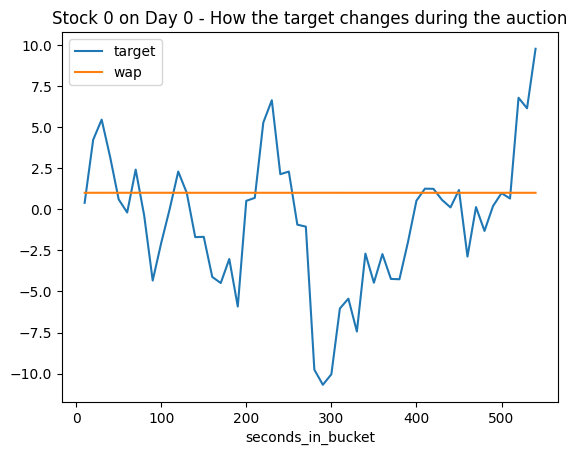

In [6]:
(
    train
    .query('stock_id ==0 & date_id ==0')
    [['seconds_in_bucket','target', 'wap']]
    .replace(0, np.nan)
    .set_index('seconds_in_bucket')
    .plot(title='Stock 0 on Day 0 - How the target changes during the auction')
)

<Axes: title={'center': 'Stock 0 on Day 0 - How the order book pricing changes during the auction'}, xlabel='seconds_in_bucket'>

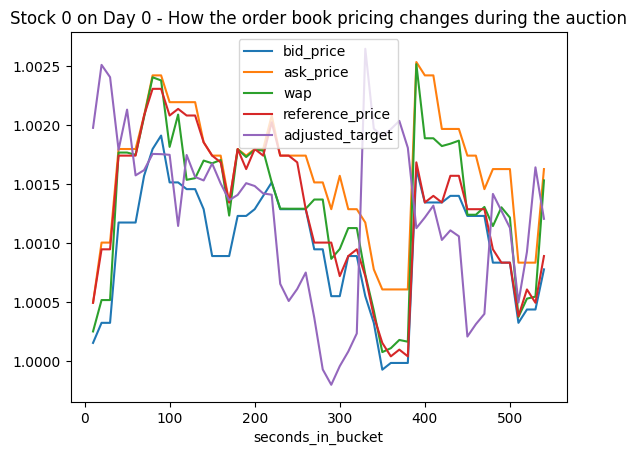

In [170]:
(
    train
    .query('stock_id ==1 & date_id ==4')
    [['seconds_in_bucket','bid_price','ask_price', 'wap', 'reference_price','adjusted_target']]
    .replace(0, np.nan)
    .set_index('seconds_in_bucket')
    .plot(title='Stock 0 on Day 0 - How the order book pricing changes during the auction')
)

In [168]:
# check outliers for normal target
total = len(train.index)
print(f"Number of rows train: {total}")
print(f"Max target: {train['target'].max()} \nMin target: {train['target'].min()} \n")

I = [200, 100, 40, 20, 10, 1, 0]
for VALUE in I:
    ge = (train['target'] >= VALUE).sum()
    le = (train['target'] <= -VALUE).sum()
    print(f"Target >= {VALUE}: {ge} \nTarget <= -{VALUE}: {le}\nProportion: { ((ge+le)/total*100):.4f} \n")


Number of rows train: 4357980
Max target: 446.07043 
Min target: -385.2898 

Target >= 200: 34 
Target <= -200: 31
Proportion: 0.0015 

Target >= 100: 429 
Target <= -100: 306
Proportion: 0.0169 

Target >= 40: 11128 
Target <= -40: 9954
Proportion: 0.4838 

Target >= 20: 95391 
Target <= -20: 94006
Proportion: 4.3460 

Target >= 10: 423174 
Target <= -10: 432231
Proportion: 19.6285 

Target >= 1: 1891603 
Target <= -1: 1927638
Proportion: 87.6379 

Target >= 0: 2162064 
Target <= -0: 2198501
Proportion: 100.0593 



In [182]:
# check outliers for adjusted target
total = len(train.index)
print(f"Number of rows train: {total}")
print(f"Max adjusted_target: {train['adjusted_target'].max()} \nMin adjusted_target: {train['adjusted_target'].min()} \n")

I = [1.05, 1, 0.5]
for VALUE in I:
    ge = (train['adjusted_target'] >= VALUE).sum()
    le = (train['adjusted_target'] <= -VALUE).sum()
    print(f"Target >= {VALUE}: {ge} \nTarget <= -{VALUE}: {le}\nProportion: { ((ge+le)/total*100):.4f} \n")

Number of rows train: 4357980
Max adjusted_target: 1.0528267896075405 
Min adjusted_target: 0.9369107820739279 

Target >= 1.05: 3 
Target <= -1.05: 0
Proportion: 0.0001 

Target >= 1: 2135241 
Target <= -1: 0
Proportion: 48.9961 

Target >= 0.5: 4357815 
Target <= -0.5: 0
Proportion: 99.9962 



<Axes: title={'center': 'Stock 0 on Day 0 - How the auction & combined book pricing changes during the auction'}, xlabel='seconds_in_bucket'>

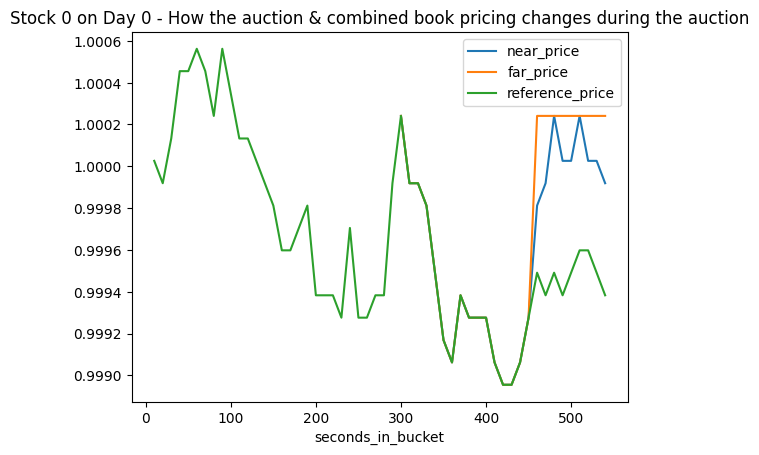

In [50]:
(
    train
    .query('stock_id ==0 & date_id ==0')
    [['seconds_in_bucket','near_price','far_price','reference_price']]
    .replace(0, np.nan)
    .set_index('seconds_in_bucket')
    .plot(title = 'Stock 0 on Day 0 - How the auction & combined book pricing changes during the auction')
)

<Axes: title={'center': 'Stock 0 on Day 0 - How the auction sizing changes during the auction period'}, xlabel='seconds_in_bucket'>

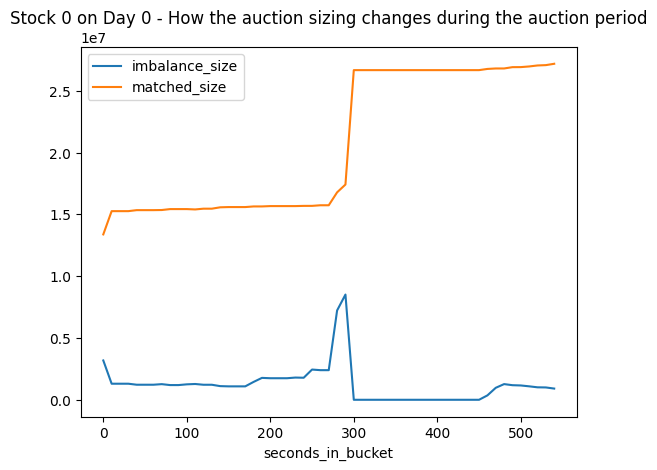

In [6]:
(
    train
    .query('stock_id ==0 & date_id ==0')
    [['seconds_in_bucket','imbalance_size','matched_size']]
    .set_index('seconds_in_bucket')
    .plot(title='Stock 0 on Day 0 - How the auction sizing changes during the auction period')
)